<a href="https://colab.research.google.com/github/Baronlegend27/academic-research-to-financial-freedom/blob/main/papers/Bodie%2C%20Z.%20(1995).%20%22On%20the%20risk%20of%20stocks%20in%20the%20long%20run.%22/Long_Run_Stock_Risk.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [6]:
# Illustration of Bodie (1995): Long Horizon Risk and Insurance Cost
# This code numerically illustrates the core argument in
# Bodie (1995) "On the Risk of Stocks in the Long Run"
#
# The paper argues that although the probability of a negative
# average return may fall with horizon, the cost of insuring
# against underperforming the risk-free rate increases with time.

import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

np.random.seed(42)

# ----------------------------
# Model Parameters
# ----------------------------
# These correspond to the standard continuous-time stock model
# used in option pricing theory (geometric Brownian motion)

S0 = 1.0              # Initial wealth (normalized to 1)
mu = 0.08             # Expected continuously compounded stock return
r = 0.02              # Risk-free rate (T-bill rate in Bodie's framing)
sigma = 0.20          # Volatility of stock returns
paths = 100000        # Number of Monte Carlo simulations
horizons = [1, 5, 10, 20, 30]  # Investment horizons in years


# ----------------------------
# Terminal Wealth Simulation
# ----------------------------
# This implements the geometric Brownian motion model:
#
#   ln(S_T) ~ Normal((mu - 0.5*sigma^2)T , sigma^2 T)
#
# This is the same underlying structure assumed in option pricing.
# Note that variance increases linearly with time (sigma^2 * T).
# That is central to Bodie's argument.

def simulate_terminal_wealth(T):
    Z = np.random.normal(size=paths)
    ST = S0 * np.exp((mu - 0.5*sigma**2)*T + sigma*np.sqrt(T)*Z)
    return ST


# ----------------------------
# Black-Scholes Put Pricing
# ----------------------------
# This computes the price of a European put option.
#
# In Bodie's paper, risk is defined as the cost of insuring
# the stock portfolio against earning less than the risk-free rate.
#
# That insurance is equivalent to a put option with strike:
#
#   K = S0 * exp(rT)
#
# This guarantees the investor at least the risk-free accumulation.

def black_scholes_put(S0, K, T, r, sigma):
    d1 = (np.log(S0/K) + (r + 0.5*sigma**2)*T) / (sigma*np.sqrt(T))
    d2 = d1 - sigma*np.sqrt(T)
    put_price = K*np.exp(-r*T)*norm.cdf(-d2) - S0*norm.cdf(-d1)
    return put_price


# Storage for results
prob_negative_avg = []  # Probability of negative average return
wealth_std = []         # Dispersion of terminal wealth
put_prices = []         # Cost of insurance (Bodie's risk measure)


# ----------------------------
# Main Loop Over Horizons
# ----------------------------
for T in horizons:

    # Simulate terminal wealth distribution
    ST = simulate_terminal_wealth(T)

    # 1. Probability of negative average annual return
    #    This captures the conventional "time diversification" idea.
    #    Many argue this probability falls with T.
    avg_return = (ST / S0)**(1/T) - 1
    prob_negative_avg.append(np.mean(avg_return < 0))

    # 2. Standard deviation of terminal wealth
    #    Shows dispersion increases with time because variance scales with T.
    wealth_std.append(np.std(ST))

    # 3. Cost of insurance against underperforming risk-free rate
    #    Strike equals risk-free accumulation.
    K = S0 * np.exp(r*T)
    put_prices.append(black_scholes_put(S0, K, T, r, sigma))


# ----------------------------
# Interpretation Guide
# ----------------------------
# After plotting:
#
# Plot 1: Probability of negative average return
#         Typically decreases with horizon.
#
# Plot 2: Standard deviation of terminal wealth
#         Increases with horizon because uncertainty widens.
#
# Plot 3: Put price (insurance cost)
#         Increases with horizon.
#
# This demonstrates Bodie's central claim:
# Even if the probability of a negative average return declines,
# the cost of insuring against underperforming the risk-free rate
# increases with time.
#
# Therefore, stocks do not necessarily become "less risky"
# when risk is defined as the cost of a guarantee.

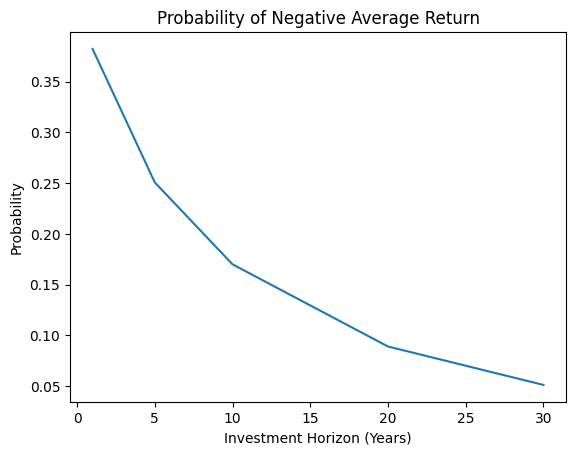

In [7]:
# Plot 1: Probability of negative average return
plt.figure()
plt.plot(horizons, prob_negative_avg)
plt.title("Probability of Negative Average Return")
plt.xlabel("Investment Horizon (Years)")
plt.ylabel("Probability")
plt.show()


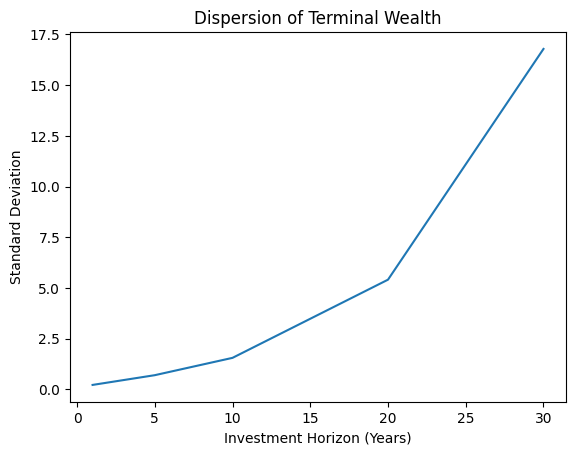

In [8]:
# Plot 2: Standard deviation of terminal wealth
plt.figure()
plt.plot(horizons, wealth_std)
plt.title("Dispersion of Terminal Wealth")
plt.xlabel("Investment Horizon (Years)")
plt.ylabel("Standard Deviation")
plt.show()

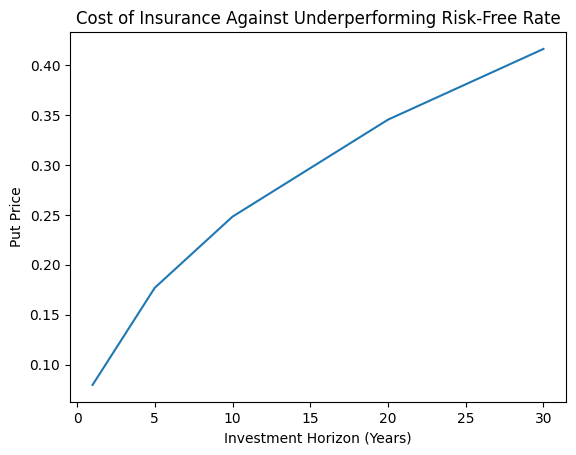

In [9]:
# Plot 3: Cost of Insurance (Put Option)
plt.figure()
plt.plot(horizons, put_prices)
plt.title("Cost of Insurance Against Underperforming Risk-Free Rate")
plt.xlabel("Investment Horizon (Years)")
plt.ylabel("Put Price")
plt.show()